**Set environment**

In [1]:
import numpy  as np
import pandas as pd
import pickle
import os

from Bio import SeqIO
import logomaker as lm

import seaborn as sns
import matplotlib.pyplot as plt

import multiprocessing
from concurrent.futures import ProcessPoolExecutor, as_completed

In [2]:
%run ../run_config_project.py
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data


You are working with      IGVF BlueSTARR
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references



## Import fasta data

**Check data existence**

In [3]:
%env FD_RES={FD_RES}

env: FD_RES=/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results


In [4]:
%%bash
echo  ${FD_RES}
ls -1 ${FD_RES}/analysis_variant_motif_richard

/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results
background_zero_order.npy
background_zero_order.tsv
batches_dev
JASPAR2024_CORE_vertebrates_non-redundant.lods.npz
JASPAR2024_CORE_vertebrates_non-redundant.pmap.npz
test_seq.fa
test_seq.fa.fai
test_variants.fa
test_variants.fa.fai
variant_closed_gof_bluestarr_flank35_obs.fa
variant_closed_gof_bluestarr_flank35_ref.fa
variant_closed_gof_bluestarr_flank35_unobs.fa
variant_closed_gof_bluestarr_flankL35R70_obs.fa
variant_closed_gof_bluestarr_flankL35R70_ref.fa
variant_closed_gof_bluestarr_flankL35R70_unobs.fa
variant_closed_gof_bluestarr.tsv.gz
variant_closed_gof_bluestarr_withseq_flank35.tsv.gz
variant_closed_gof_bluestarr_withseq_flankL35R70.tsv.gz


In [7]:
%%bash
echo  ${FD_RES}; echo
FDIRY=${FD_RES}/analysis_variant_motif_richard/batches_dev
ls -1 ${FDIRY}/variant_closed_gof_bluestarr_*fa | xargs -n 1 basename

/hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results

variant_closed_gof_bluestarr_flank35_dev10000_obs.fa
variant_closed_gof_bluestarr_flank35_dev10000_ref.fa
variant_closed_gof_bluestarr_flank35_dev10000_unobs.fa
variant_closed_gof_bluestarr_flank35_dev1000_obs.fa
variant_closed_gof_bluestarr_flank35_dev1000_ref.fa
variant_closed_gof_bluestarr_flank35_dev1000_unobs.fa
variant_closed_gof_bluestarr_flank35_dev100_obs.fa
variant_closed_gof_bluestarr_flank35_dev100_ref.fa
variant_closed_gof_bluestarr_flank35_dev100_unobs.fa
variant_closed_gof_bluestarr_flankL35R70_dev10000_obs.fa
variant_closed_gof_bluestarr_flankL35R70_dev10000_ref.fa
variant_closed_gof_bluestarr_flankL35R70_dev10000_unobs.fa
variant_closed_gof_bluestarr_flankL35R70_dev1000_obs.fa
variant_closed_gof_bluestarr_flankL35R70_dev1000_ref.fa
variant_closed_gof_bluestarr_flankL35R70_dev1000_unobs.fa
variant_closed_gof_bluestarr_flankL35R70_dev100_obs.fa
variant_closed_gof_bluestarr_flankL35R70_dev100_ref.fa
variant_closed_go

**Import data**

In [8]:
### set file directory
txt_fdiry = os.path.join(FD_RES, "analysis_variant_motif_richard", "batches_dev")

txt_fpath_ref   = os.path.join(txt_fdiry, "variant_closed_gof_bluestarr_flankL35R70_dev100_ref.fa")
txt_fpath_obs   = os.path.join(txt_fdiry, "variant_closed_gof_bluestarr_flankL35R70_dev100_obs.fa")
txt_fpath_unobs = os.path.join(txt_fdiry, "variant_closed_gof_bluestarr_flankL35R70_dev100_unobs.fa")

### import data
lst_seq_ref   = list(SeqIO.parse(txt_fpath_ref,   "fasta"))
lst_seq_obs   = list(SeqIO.parse(txt_fpath_obs,   "fasta"))
lst_seq_unobs = list(SeqIO.parse(txt_fpath_unobs, "fasta"))

**check imported data**

In [9]:
print(type(lst_seq_ref[0]))

<class 'Bio.SeqRecord.SeqRecord'>


In [10]:
print(lst_seq_ref[0])

ID: chr4:74487586:A:G:C
Name: chr4:74487586:A:G:C
Description: chr4:74487586:A:G:C
Number of features: 0
Seq('ACATGTGTGTATGCTTGTCTATATACACTGTATGAAGCAAGAGGAGAAAATACT...TTG')


In [11]:
print(lst_seq_obs[0])

ID: chr4:74487586:A:G:C
Name: chr4:74487586:A:G:C
Description: chr4:74487586:A:G:C
Number of features: 0
Seq('ACATGTGTGTATGCTTGTCTATATACACTGTATGAGGCAAGAGGAGAAAATACT...TTG')


In [12]:
print(lst_seq_unobs[0])

ID: chr4:74487586:A:G:C
Name: chr4:74487586:A:G:C
Description: chr4:74487586:A:G:C
Number of features: 0
Seq('ACATGTGTGTATGCTTGTCTATATACACTGTATGACGCAAGAGGAGAAAATACT...TTG')


In [13]:
### check data
assert len(lst_seq_ref) == len(lst_seq_obs) == len(lst_seq_unobs)
num_total = len(lst_seq_ref)
print("Total variants:", num_total)

Total variants: 100


In [14]:
lst = [rec.id for rec in lst_seq_ref]
lst[:20]

['chr4:74487586:A:G:C',
 'chr9:135685432:G:G:C',
 'chr1:173251490:G:G:C',
 'chr1:147523391:G:G:C',
 'chr18:54580749:A:G:T',
 'chr7:80949454:A:G:C',
 'chr15:42051620:A:G:C',
 'chr6:126250573:G:G:T',
 'chr2:6818290:C:C:G',
 'chr8:1743502:G:G:T',
 'chr14:59895257:C:C:G',
 'chr17:77860722:C:C:G',
 'chr12:78839763:G:G:C',
 'chr7:148668760:G:G:C',
 'chr2:235081006:G:G:C',
 'chr1:16238967:A:A:C',
 'chr16:27137957:G:G:C',
 'chr15:80030566:C:T:G',
 'chr18:57253271:T:C:G',
 'chr13:71884599:T:C:G']

## Import motif data

In [15]:
### set file directory
txt_fdiry = os.path.join(FD_RES, "analysis_variant_motif_richard")
txt_fname = "JASPAR2024_CORE_vertebrates_non-redundant.lods.npz"
txt_fpath = os.path.join(txt_fdiry, txt_fname)

### import data
obj = np.load(txt_fpath, allow_pickle=True)

### assign and show
dct_motif_lods = obj["lods"].item()
print(f"Loaded LODS for {len(dct_motif_lods)} motifs from {txt_fpath}\n")

Loaded LODS for 879 motifs from /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results/analysis_variant_motif_richard/JASPAR2024_CORE_vertebrates_non-redundant.lods.npz



In [16]:
### set file directory
txt_fdiry = os.path.join(FD_RES, "analysis_variant_motif_richard")
txt_fname = "JASPAR2024_CORE_vertebrates_non-redundant.pmap.npz"
txt_fpath = os.path.join(txt_fdiry, txt_fname)

### import data
obj = np.load(txt_fpath, allow_pickle=True)

### assign and show
dct_motif_model = obj["dct_results"].item()  # motif_name -> {arr_lod_WxB, grid, ccdf, Tbind, ...}
print(f"Loaded PMAPs for {len(dct_motif_model)} motifs from {txt_fpath}\n")

Loaded PMAPs for 879 motifs from /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results/analysis_variant_motif_richard/JASPAR2024_CORE_vertebrates_non-redundant.pmap.npz



**Show imported data**

In [15]:
print(dct_motif_lods["MA0002.3 Runx1"])

[[ -2.34761369   1.51832077  -1.33382295   0.07182151]
 [ -3.45723818 -17.5135527   -5.74563655   1.63313274]
 [-18.25591248  -2.31894973   2.31737325  -3.55781004]
 [ -2.8471847   -1.55908373  -2.42370845   1.45910334]
 [-18.25591248 -17.5135527    2.40338469  -5.58529078]
 [ -5.20266535  -3.15545099   2.29875757  -2.74657169]
 [ -5.9682001    0.09608777  -0.58144792   1.10120975]
 [ -2.25670519   0.30709997  -2.21314147   1.08604615]
 [ -0.32434391  -1.24398767  -0.37806579   0.75455922]]


In [16]:
arr = np.array([lods.shape[0] for lods in dct_motif_lods.values()])
res = np.array([np.min(arr), np.mean(arr), np.median(arr), np.max(arr)])
res = np.round(res, 2)
print(res)

[ 5.   10.09  9.   33.  ]


In [17]:
print(dct_motif_model["MA0002.3 Runx1"].keys())

dict_keys(['arr_num_score_grid', 'arr_num_score_pmf', 'arr_num_score_ccdf', 'arr_lod_WxB', 'num_Tbind', 'num_alpha', 'num_precision'])


In [18]:
print(dct_motif_model["MA0002.3 Runx1"]["arr_lod_WxB"])

[[ -2.34761369   1.51832077  -1.33382295   0.07182151]
 [ -3.45723818 -17.5135527   -5.74563655   1.63313274]
 [-18.25591248  -2.31894973   2.31737325  -3.55781004]
 [ -2.8471847   -1.55908373  -2.42370845   1.45910334]
 [-18.25591248 -17.5135527    2.40338469  -5.58529078]
 [ -5.20266535  -3.15545099   2.29875757  -2.74657169]
 [ -5.9682001    0.09608777  -0.58144792   1.10120975]
 [ -2.25670519   0.30709997  -2.21314147   1.08604615]
 [ -0.32434391  -1.24398767  -0.37806579   0.75455922]]


## Scan sequences by motifs

**Helper function**

In [19]:
from motifdelta.scan import scan_motif_both_strands

In [20]:
def scan_one_sequence(seq_record, dct_arr_motif_Wx4, num_target_len):
    """
    Scan all motifs on a single sequence.
    Returns (seq_id, {motif_name: {"forward": fwd_scores, "reverse": rev_scores}}).

    Parameters
    ----------
    seq_record : SeqRecord or object with `.id` and `.seq`
        Sequence record, each with `.id` and `.seq` attributes.
    dct_arr_motif_Wx4 : dict
        Dictionary of motif_name -> motif matrix (W,4)
        
    Returns
    -------
    dict
        {seq_id -> {motif_name: {"forward": arr, "reverse": arr}}}
    """
    ### init: parse sequence id and string
    txt_seq_idx = str(seq_record.id)
    txt_seq_str = str(seq_record.seq)
    num_seq_len = len(txt_seq_str)
    
    ### init: collect results
    dct_results = {}

    ### test: check seqeunce length consistency
    if num_seq_len != num_target_len:
        raise ValueError(f"Sequence {txt_seq_idx} length {num_seq_len} != target {num_target_len}")
        
    ### loop through each motif and scan
    for txt_motif_name, arr_motif_Wx4 in dct_arr_motif_Wx4.items():
        arr_score_fwd, arr_score_rev = scan_motif_both_strands(txt_seq_str, arr_motif_Wx4)

        num_pad_len = num_seq_len - len(arr_score_fwd)
        if num_pad_len > 0:
            arr_score_fwd = np.pad(arr_score_fwd, (0, num_pad_len), constant_values=np.nan)
            arr_score_rev = np.pad(arr_score_rev, (0, num_pad_len), constant_values=np.nan)
        
        dct_results[txt_motif_name] = {
            "forward": arr_score_fwd,
            "reverse": arr_score_rev
        }

    return txt_seq_idx, dct_results

In [21]:
def scan_sequence_batch_parallel(lst_seq_record, dct_arr_motif_Wx4, num_workers=None):
    """
    Parallel version of sequence scanning using multiple CPU cores.

    Parameters
    ----------
    lst_seq_record : list[SeqRecord]
        List of sequence records, each with `.id` and `.seq`.
    dct_arr_motif_Wx4 : dict
        Dictionary of motif_name -> motif matrix (W,4)
    num_workers : int, optional
        Number of parallel processes. Defaults to available CPU cores.

    Returns
    -------
    dict
        {seq_id: {motif_name: {"forward": arr, "reverse": arr}}}
    """
    ### init: set number of core for parallelization
    ### default: #{available CPU} - 1
    if num_workers is None:
        num_workers = max(1, multiprocessing.cpu_count() - 1)

    ### init: final results
    dct_results = {}

    ### Assume all sequences are the same length, so we can grab the first one.
    num_target_len = len(lst_seq_record[0].seq)
    
    ### loop through each sequence and scan for all motifs in dictionary
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        ### assign workers
        futures = [
            executor.submit(scan_one_sequence, seq_record, dct_arr_motif_Wx4, num_target_len)
            for seq_record in lst_seq_record
        ]
        
        ### execute workers
        for f in as_completed(futures):
            idx, res = f.result()
            dct_results[idx] = res

    return dct_results

**Test: sanity check**

In [22]:
%%time
txt_seq_idx, dct_motif_scan_test = scan_one_sequence(lst_seq_ref[0], dct_motif_lods, 71)
txt_motif_idx = list(dct_motif_scan_test.keys())[0]

print("Seq index:    ", txt_seq_idx)
print("Seq length:   ", len(lst_seq_ref[0].seq))
print("Motif index:  ", txt_motif_idx)
print("Forward shape:", dct_motif_scan_test[txt_motif_idx]["forward"].shape)
print("Reverse shape:", dct_motif_scan_test[txt_motif_idx]["reverse"].shape)
print("Tail:         ", dct_motif_scan_test[txt_motif_idx]["forward"][-5:])

Seq index:     chr4:74487586:A:G:C
Seq length:    71
Motif index:   MA0002.3 Runx1
Forward shape: (71,)
Reverse shape: (71,)
Tail:          [nan nan nan nan nan]
CPU times: user 155 ms, sys: 2.71 ms, total: 157 ms
Wall time: 157 ms


In [23]:
%%time
dct_motif_scan_test = scan_sequence_batch_parallel(
    lst_seq_ref[:5],
    dct_motif_lods,
    num_workers=10
)

txt_seq_idx   = list(dct_motif_scan_test.keys())[0]
txt_motif_idx = list(dct_motif_scan_test[txt_seq_idx].keys())[0]

print("Seq:          ", txt_seq_idx)
print("Motif:        ", txt_motif_idx)
print("Forward shape:", dct_motif_scan_test[txt_seq_idx][txt_motif_idx]["forward"].shape)
print("Reverse shape:", dct_motif_scan_test[txt_seq_idx][txt_motif_idx]["reverse"].shape)

Seq:           chr1:173251490:G:G:C
Motif:         MA0002.3 Runx1
Forward shape: (71,)
Reverse shape: (71,)
CPU times: user 33.9 ms, sys: 488 ms, total: 521 ms
Wall time: 794 ms


**Execution: scanning sequences by motifs**

In [24]:
print(multiprocessing.cpu_count())

94


In [25]:
%%time
dct_motif_scan_ref = scan_sequence_batch_parallel(
    lst_seq_ref,
    dct_motif_lods,
    num_workers=10
)

CPU times: user 921 ms, sys: 639 ms, total: 1.56 s
Wall time: 2.63 s


In [26]:
%%time
dct_motif_scan_obs = scan_sequence_batch_parallel(
    lst_seq_obs,
    dct_motif_lods,
    num_workers=10
)

CPU times: user 1.03 s, sys: 679 ms, total: 1.71 s
Wall time: 2.78 s


In [27]:
%%time
dct_motif_scan_unobs = scan_sequence_batch_parallel(
    lst_seq_unobs,
    dct_motif_lods,
    num_workers=10
)

CPU times: user 948 ms, sys: 681 ms, total: 1.63 s
Wall time: 2.77 s


## Calculate delta from the scanning scores

**Helper function**

In [28]:
def build_tensor_from_scan_dict(
    dct_motif_scan, 
    lst_motif_name, 
    lst_seq_order=None,
    num_target_len=71, 
    dtype=np.float32):
    """
    Convert {seq → motif → {'forward','reverse'}} to (N, M, L, 2) tensor.

    Parameters
    ----------
    dct_motif_scan : dict
        Nested dict of motif scan results for multiple sequences.
    lst_motif_index : list[str]
        Ordered list of motif names to ensure consistent motif order.
    num_target_len : int
        Target sequence length (padded length, e.g., 71).
    dtype : numpy dtype
        Data type for output tensor.

    Returns
    -------
    tuple
        (lst_seq_idx, arr_motif_out)
        lst_seq_idx: list of sequence IDs (order)
        arr_motif_out: numpy array of shape (N, M, L, 2)
    """
    # Enforce consistent sequence order
    if lst_seq_order is None:
        lst_seq_order = sorted(dct_motif_scan.keys())
    
    num_seq_cnt   = len(lst_seq_order)
    num_motif_cnt = len(lst_motif_name)
    arr_motif_out = np.full((num_seq_cnt, num_motif_cnt, num_target_len, 2),
                            np.nan, dtype=dtype)

    for num_seq_idx, txt_seq_idx in enumerate(lst_seq_order):
        dct = dct_motif_scan[txt_seq_idx]
        for num_motif_idx, txt_motif_idx in enumerate(lst_motif_name):
            arr_motif_out[num_seq_idx, num_motif_idx, :, 0] = dct[txt_motif_idx]["forward"]
            arr_motif_out[num_seq_idx, num_motif_idx, :, 1] = dct[txt_motif_idx]["reverse"]

    return lst_seq_order, arr_motif_out

**Test**

In [29]:
lst_motif_name = sorted(dct_motif_lods.keys())
lst_seq_idx, arr_motif_scan_ref = build_tensor_from_scan_dict(dct_motif_scan_ref, lst_motif_name)

print(arr_motif_scan_ref.shape)
print("Example motif tail:", arr_motif_scan_ref[0, 0, :5, 0])
print("Example motif tail:", arr_motif_scan_ref[0, 0, -5:, 0])

(100, 879, 71, 2)
Example motif tail: [-25.369837   -7.4064136 -29.368116  -14.555505  -13.155853 ]
Example motif tail: [nan nan nan nan nan]


**Execute**

In [30]:
lst_seq_order = [rec.id for rec in lst_seq_ref] # preserve the original variant order
lst_motif_name = list(dct_motif_lods.keys())    # preserve teh original motif order

lst_seq_idx, arr_motif_scan_ref   = build_tensor_from_scan_dict(dct_motif_scan_ref,   lst_motif_name, lst_seq_order)
lst_seq_idx, arr_motif_scan_obs   = build_tensor_from_scan_dict(dct_motif_scan_obs,   lst_motif_name, lst_seq_order)
lst_seq_idx, arr_motif_scan_unobs = build_tensor_from_scan_dict(dct_motif_scan_unobs, lst_motif_name, lst_seq_order)

arr_motif_delta = arr_motif_scan_unobs - arr_motif_scan_obs

print(arr_motif_delta.shape)
print("Δ mean (ignore NaN):", np.nanmean(arr_motif_delta))
print("Example motif Δ head:", arr_motif_delta[0, 0,  0:10, 0])
print("Example motif Δ tail:", arr_motif_delta[0, 0, 30:40, 0])

(100, 879, 71, 2)
Δ mean (ignore NaN): 0.0034405077
Example motif Δ head: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Example motif Δ tail: [ -5.4542103 -19.916937    0.864624   -4.636322  -11.767914    2.8521461
   0.          0.          0.          0.       ]


**Test: sanity check**

In [31]:
txt_seq_ref   = str(lst_seq_ref[0].seq)
txt_seq_obs   = str(lst_seq_obs[0].seq)
txt_seq_unobs = str(lst_seq_unobs[0].seq)
print(txt_seq_ref == txt_seq_obs)     # should be True except one base
print(txt_seq_ref == txt_seq_unobs)   # should be True except one base
print(txt_seq_ref)
print(txt_seq_obs)
print(txt_seq_unobs)

False
False
ACATGTGTGTATGCTTGTCTATATACACTGTATGAAGCAAGAGGAGAAAATACTCATGAATTCTAGGAACT
ACATGTGTGTATGCTTGTCTATATACACTGTATGAGGCAAGAGGAGAAAATACTCATGAATTCTAGGAACT
ACATGTGTGTATGCTTGTCTATATACACTGTATGACGCAAGAGGAGAAAATACTCATGAATTCTAGGAACT


In [32]:
lst_seq_idx = list(dct_motif_scan_obs.keys())
print(list(dct_motif_scan_obs.keys())[:5])
print(list(dct_motif_scan_unobs.keys())[:5])
print(set(lst_seq_idx) == set(dct_motif_scan_unobs.keys()))

['chr4:74487586:A:G:C', 'chr1:147523391:G:G:C', 'chr15:42051620:A:G:C', 'chr6:126250573:G:G:T', 'chr9:135685432:G:G:C']
['chr4:74487586:A:G:C', 'chr18:54580749:A:G:T', 'chr1:147523391:G:G:C', 'chr1:173251490:G:G:C', 'chr15:42051620:A:G:C']
True


[-22.27977712 -34.9634626  -10.49413009 -28.80467865  -5.65400098
 -36.55871305 -10.53167704 -21.16277982 -24.38755537 -26.47898256
  -8.17129826 -40.91175645 -12.54748631 -18.37046005 -13.7216549
 -23.18124122 -21.93530754 -20.07215895 -21.33833595 -12.90213025
 -23.31125508 -20.10238748 -23.93943904 -30.17521434 -23.14511407
 -24.91198399 -35.79585046  -5.37297862 -29.02405444 -22.0321602
 -40.89405317   1.75054816 -27.92935909 -29.33752521 -17.27452545
 -31.73585728 -29.18774156 -32.33909715 -20.58409251 -28.77348441
 -23.65406765 -11.63006733 -25.96420207 -24.07673152 -21.5794257
 -19.75065861 -21.55816149 -39.1536502    1.21290204 -23.14295467
 -42.578617   -14.06111542 -15.18520218 -29.36617169 -33.70705943
  -6.19945717 -22.10132011 -29.21259295 -18.7814005  -23.54810833
 -28.206738   -13.35034114 -23.28547929          nan          nan
          nan          nan          nan          nan          nan
          nan]
[-22.27977712 -34.9634626  -10.49413009 -28.80467865  -5.6540009

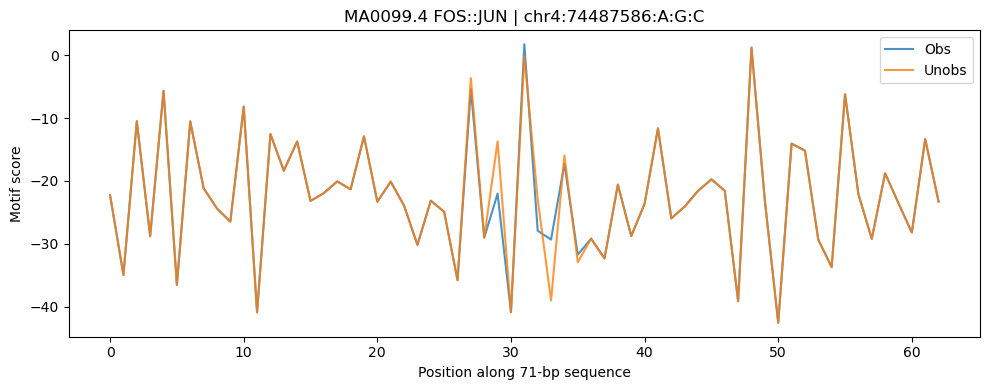

In [33]:
txt_motif_idx = "MA0099.4 FOS::JUN"
txt_seq_idx   = lst_seq_idx[0]
strand        = 0  # forward

arr_obs   = dct_motif_scan_obs[txt_seq_idx][txt_motif_idx]["forward"]
arr_unobs = dct_motif_scan_unobs[txt_seq_idx][txt_motif_idx]["forward"]

print(arr_obs)
print(arr_unobs)

plt.figure(figsize=(10,4))
plt.plot(arr_obs,   label="Obs", alpha=0.8)
plt.plot(arr_unobs, label="Unobs", alpha=0.8)
plt.legend()
plt.title(f"{txt_motif_idx} | {txt_seq_idx}")
plt.xlabel("Position along 71-bp sequence")
plt.ylabel("Motif score")
plt.tight_layout()
plt.show()

[-22.279778  -34.963463  -10.49413   -28.804678   -5.6540008 -36.558712
 -10.531677  -21.16278   -24.387556  -26.478983   -8.171298  -40.911755
 -12.547486  -18.37046   -13.721655  -23.181242  -21.935308  -20.072159
 -21.338335  -12.90213   -23.311255  -20.102388  -23.93944   -30.175215
 -23.145115  -24.911983  -35.79585    -5.3729787 -29.024054  -22.03216
 -40.894054    1.7505481 -27.92936   -29.337524  -17.274525  -31.735857
 -29.187742  -32.339096  -20.584093  -28.773485  -23.654068  -11.630067
 -25.964203  -24.07673   -21.579426  -19.750658  -21.55816   -39.15365
   1.2129021 -23.142954  -42.578617  -14.061115  -15.185203  -29.36617
 -33.707058   -6.199457  -22.10132   -29.212593  -18.7814    -23.54811
 -28.206738  -13.350341  -23.285479          nan         nan         nan
         nan         nan         nan         nan         nan]
[-22.279778   -34.963463   -10.49413    -28.804678    -5.6540008
 -36.558712   -10.531677   -21.16278    -24.387556   -26.478983
  -8.171298   -40.91

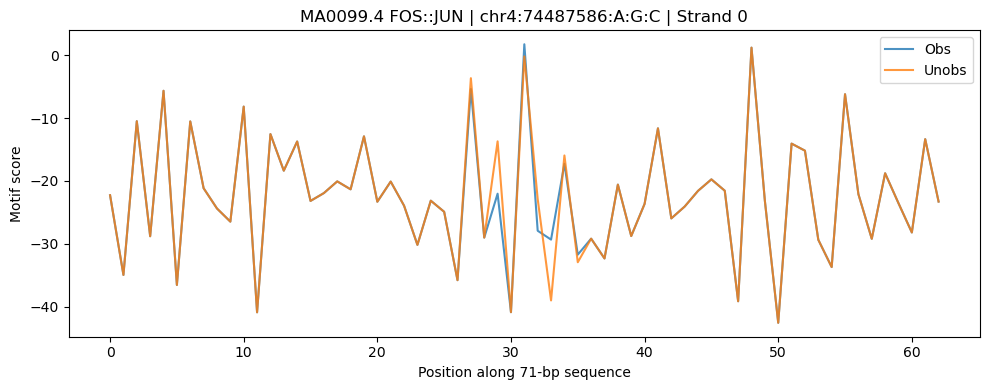

In [34]:
txt_motif_idx = "MA0099.4 FOS::JUN"
txt_seq_idx   = lst_seq_idx[0]
strand        = 0  # forward

# Locate sequence and motif indices
i_seq   = lst_seq_idx.index(txt_seq_idx)
i_motif = lst_motif_name.index(txt_motif_idx)

# Extract the score arrays from the correct tensors
arr_obs   = arr_motif_scan_obs[i_seq, i_motif, :, strand]
arr_unobs = arr_motif_scan_unobs[i_seq, i_motif, :, strand]
print(arr_obs)
print(arr_unobs)

# Plot
plt.figure(figsize=(10,4))
plt.plot(arr_obs,   label="Obs", alpha=0.8)
plt.plot(arr_unobs, label="Unobs", alpha=0.8)
plt.legend()
plt.title(f"{txt_motif_idx} | {txt_seq_idx} | Strand {strand}")
plt.xlabel("Position along 71-bp sequence")
plt.ylabel("Motif score")
plt.tight_layout()
plt.show()

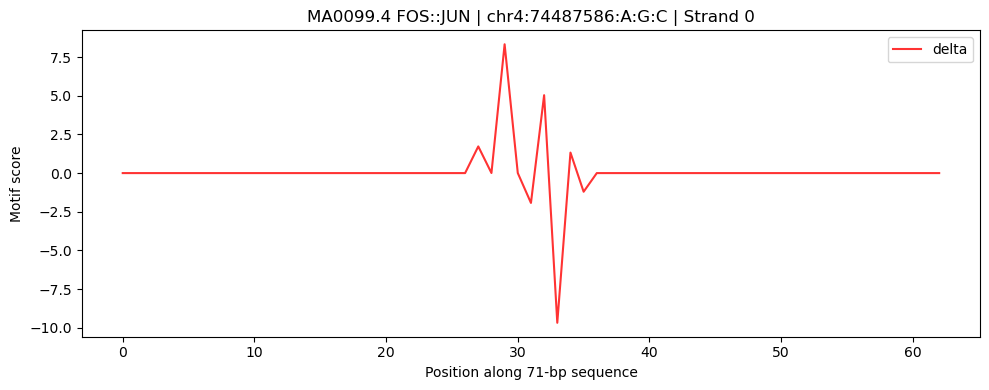

In [35]:
txt_motif_idx = "MA0099.4 FOS::JUN"
txt_seq_idx   = lst_seq_idx[0]
strand        = 0  # forward

# Locate sequence and motif indices
i_seq   = lst_seq_idx.index(txt_seq_idx)
i_motif = lst_motif_name.index(txt_motif_idx)

# Extract the score arrays from the correct tensors
arr_obs   = arr_motif_scan_obs[i_seq, i_motif, :, strand]
arr_unobs = arr_motif_scan_unobs[i_seq, i_motif, :, strand]
arr_delta = arr_unobs - arr_obs

# Plot
plt.figure(figsize=(10,4))
plt.plot(arr_delta, label="delta", alpha=0.8, c = "red")
plt.legend()
plt.title(f"{txt_motif_idx} | {txt_seq_idx} | Strand {strand}")
plt.xlabel("Position along 71-bp sequence")
plt.ylabel("Motif score")
plt.tight_layout()
plt.show()

**visualize**

(100, 71)


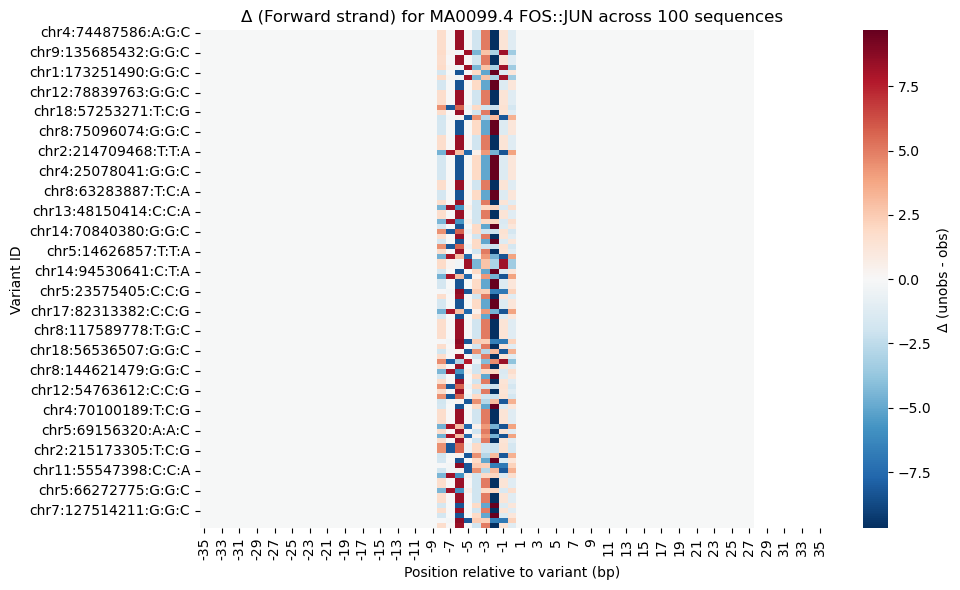

In [36]:
### Select motif and strand
txt_motif_target = "MA0099.4 FOS::JUN"
num_motif_idx = lst_motif_name.index(txt_motif_target)
num_strand    = 0  # 0 = forward, 1 = reverse

### Extract Δ matrix: (N_variants × 71 positions)
mat_motif_delta = arr_motif_delta[:, num_motif_idx, :, num_strand]
print(mat_motif_delta.shape)   # (N, 71)

### Build coordinate labels centered at 0 (variant base = 0)
num_motif_window = mat_motif_delta.shape[1]
num_half_length  = num_motif_window // 2

if num_motif_window % 2 == 0:
    vec_num_pos_label = np.arange(-num_half_length, num_half_length)
else:
    vec_num_pos_label = np.arange(-num_half_length, num_half_length + 1)

### Wrap into DataFrame for seaborn
dat_motif_delta = pd.DataFrame(
    mat_motif_delta,
    index=lst_seq_idx,
    columns=vec_num_pos_label
)

### Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(dat_motif_delta, cmap="RdBu_r", center=0,
            cbar_kws={"label": "Δ (unobs - obs)"})
plt.title(f"Δ (Forward strand) for {txt_motif_target} across {mat_motif_delta.shape[0]} sequences")
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Variant ID")
plt.tight_layout()
plt.show()

## Weight calculation

In [37]:
### dct_motif_model[motif_id]["num_Tbind"] exists from your PMAP npz
arr_motif_Tbind    = np.array([dct_motif_model[m]["num_Tbind"] for m in lst_motif_name], dtype=np.float32)  # (M,)
arr_motif_Tbind_4D = arr_motif_Tbind[None, :, None, None]  # broadcast to (1,M,1,1)

### elementwise max across alleles, same shape as tensors: (N,M,71,2)
arr_motif_strength = np.maximum(arr_motif_scan_obs, arr_motif_scan_unobs)

### mask out padded NaNs
arr_motif_valid = np.isfinite(arr_motif_strength)

### hard mask at Tbind
arr_motif_weight_hard = (arr_motif_strength >= arr_motif_Tbind_4D).astype(np.float32)
arr_motif_weight_hard = np.where(arr_motif_valid, arr_motif_weight_hard, 0.0)  # kill NaNs

### soft logistic around Tbind
k = 1  # bits; tweak 1–2 if you want a sharper/softer transition\

# Compute safely: clip the argument to a reasonable range (e.g., ±60)
z = -(arr_motif_strength - arr_motif_Tbind_4D) / k
z = np.clip(z, -60, 60)
arr_motif_weight_soft = 1.0 / (1.0 + np.exp(z))

# Mask invalid (NaN) positions
arr_motif_weight_soft = np.where(arr_motif_valid, arr_motif_weight_soft, 0.0)

print(np.nanmin(arr_motif_weight_soft), np.nanmax(arr_motif_weight_soft))
print(pd.DataFrame(arr_motif_weight_soft.reshape(-1)).describe())

0.0 1.0
                  0
count  1.248180e+07
mean   1.349229e-03
std    2.963423e-02
min    0.000000e+00
25%    8.756512e-27
50%    8.104508e-19
75%    8.577557e-12
max    1.000000e+00


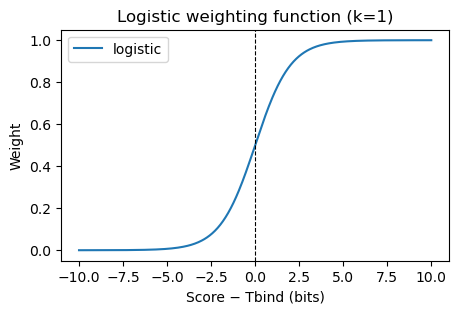

In [38]:
import matplotlib.pyplot as plt
x = np.linspace(-10, 10, 400)

plt.figure(figsize=(5, 3))
plt.plot(x, 1 / (1 + np.exp(-x)), label="logistic")
plt.axvline(0, color="k", linestyle="--", lw=0.8)
plt.title(f"Logistic weighting function (k={k})")
plt.xlabel("Score − Tbind (bits)")
plt.ylabel("Weight")
plt.legend()
plt.show()

## Weighted delta

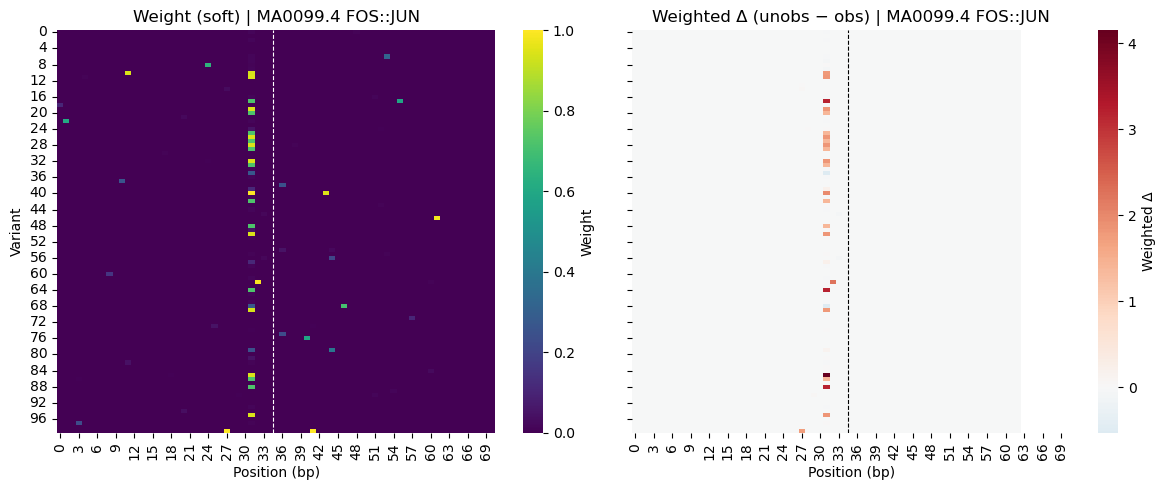

In [39]:
# -------------------------------------------------------------
# 1. Select motif and strand
# -------------------------------------------------------------
motif   = "MA0099.4 FOS::JUN"   # pick any motif of interest
strand  = 0                      # 0 = forward, 1 = reverse
i_motif = lst_motif_name.index(motif)

# -------------------------------------------------------------
# 2. Extract matrices across variants (N × 71)
# -------------------------------------------------------------
mat_w  = arr_motif_weight_soft[:, i_motif, :, strand]   # or arr_motif_weight_hard
mat_dw = (arr_motif_delta * arr_motif_weight_soft)[:, i_motif, :, strand]

# -------------------------------------------------------------
# 3. Prepare coordinate labels centered at the variant
# -------------------------------------------------------------
num_pos = mat_w.shape[1]
x = np.arange(num_pos) - (num_pos // 2)

# -------------------------------------------------------------
# 4. Plot side-by-side heatmaps
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.heatmap(mat_w, cmap="viridis", vmin=0, vmax=1, ax=axes[0], cbar_kws={"label": "Weight"})
axes[0].axvline(num_pos//2, color="w", ls="--", lw=0.8)
axes[0].set_title(f"Weight (soft) | {motif}")
axes[0].set_xlabel("Position (bp)")
axes[0].set_ylabel("Variant")

sns.heatmap(mat_dw, cmap="RdBu_r", center=0, ax=axes[1],
            cbar_kws={"label": "Weighted Δ"})
axes[1].axvline(num_pos//2, color="k", ls="--", lw=0.8)
axes[1].set_title(f"Weighted Δ (unobs − obs) | {motif}")
axes[1].set_xlabel("Position (bp)")

plt.tight_layout()
plt.show()

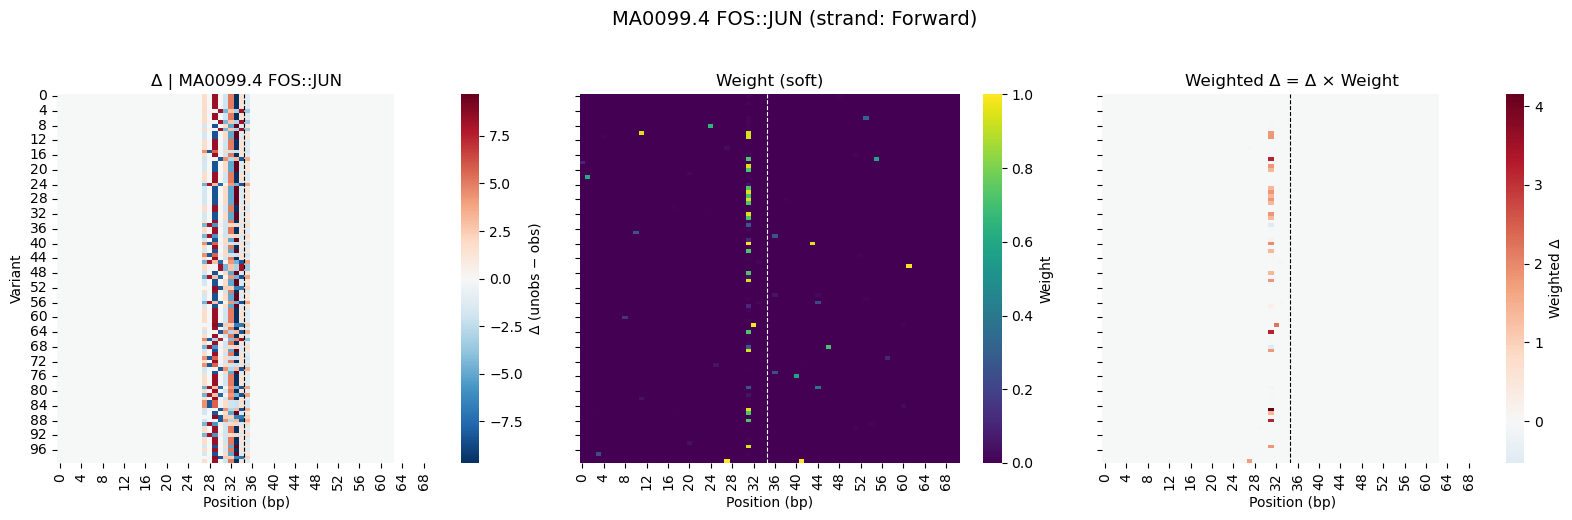

In [40]:
# -------------------------------------------------------------
# 1. Select motif and strand
# -------------------------------------------------------------
motif   = "MA0099.4 FOS::JUN"   # choose any motif
strand  = 0                      # 0 = forward, 1 = reverse
i_motif = lst_motif_name.index(motif)

# -------------------------------------------------------------
# 2. Extract matrices (N × 71)
# -------------------------------------------------------------
mat_delta = arr_motif_delta[:, i_motif, :, strand]
mat_w     = arr_motif_weight_soft[:, i_motif, :, strand]   # or arr_motif_weight_hard
mat_dw    = (arr_motif_delta * arr_motif_weight_soft)[:, i_motif, :, strand]

# -------------------------------------------------------------
# 3. Coordinate labels (center = variant)
# -------------------------------------------------------------
num_pos = mat_delta.shape[1]
center_pos = num_pos // 2
x = np.arange(num_pos) - center_pos

# -------------------------------------------------------------
# 4. 3-panel heatmap layout
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# Δ
sns.heatmap(mat_delta, cmap="RdBu_r", center=0, ax=axes[0],
            cbar_kws={"label": "Δ (unobs − obs)"})
axes[0].axvline(center_pos, color="k", ls="--", lw=0.8)
axes[0].set_title(f"Δ | {motif}")
axes[0].set_xlabel("Position (bp)")
axes[0].set_ylabel("Variant")

# Weight
sns.heatmap(mat_w, cmap="viridis", vmin=0, vmax=1, ax=axes[1],
            cbar_kws={"label": "Weight"})
axes[1].axvline(center_pos, color="w", ls="--", lw=0.8)
axes[1].set_title("Weight (soft)")
axes[1].set_xlabel("Position (bp)")

# Weighted Δ
sns.heatmap(mat_dw, cmap="RdBu_r", center=0, ax=axes[2],
            cbar_kws={"label": "Weighted Δ"})
axes[2].axvline(center_pos, color="k", ls="--", lw=0.8)
axes[2].set_title("Weighted Δ = Δ × Weight")
axes[2].set_xlabel("Position (bp)")

strand_label = "Forward" if strand == 0 else "Reverse"
plt.suptitle(f"{motif} (strand: {strand_label})", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

In [41]:
# -------------------------------------------------------------
# 1. Select motif & strand
# -------------------------------------------------------------
motif   = "MA0099.4 FOS::JUN"
strand  = 0
i_motif = lst_motif_name.index(motif)

# -------------------------------------------------------------
# 2. Extract matrices (N × 71)
# -------------------------------------------------------------
mat_delta = arr_motif_delta[:, i_motif, :, strand]
mat_w     = arr_motif_weight_soft[:, i_motif, :, strand]
mat_dw    = (arr_motif_delta * arr_motif_weight_soft)[:, i_motif, :, strand]

num_pos   = mat_delta.shape[1]
center_bp = num_pos // 2
x = np.arange(num_pos) - center_bp

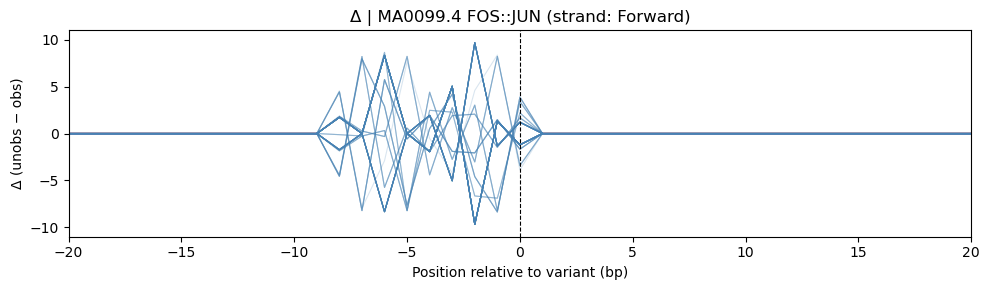

In [42]:
plt.figure(figsize=(10,3))
for vec in mat_delta:
    plt.plot(x, vec, color="steelblue", alpha=0.2, lw=0.8)
plt.axvline(0, color="k", ls="--", lw=0.8)
plt.title(f"Δ | {motif} (strand: {strand_label})")
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Δ (unobs − obs)")
plt.xlim(-20, 20)
plt.ylim(-11, 11)
plt.tight_layout()
plt.show()

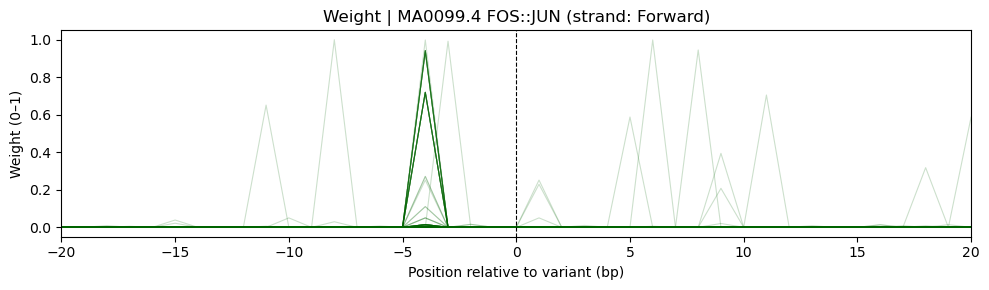

In [43]:
plt.figure(figsize=(10,3))
for vec in mat_w:
    plt.plot(x, vec, color="darkgreen", alpha=0.2, lw=0.8)
plt.axvline(0, color="k", ls="--", lw=0.8)
plt.title(f"Weight | {motif} (strand: {strand_label})")
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Weight (0–1)")
plt.xlim(-20, 20)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

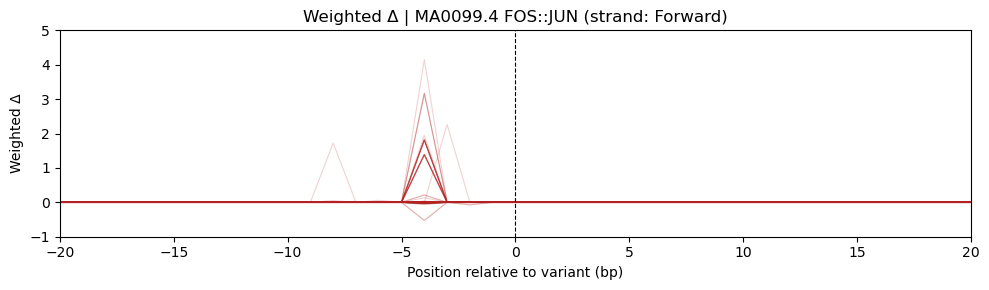

In [44]:
plt.figure(figsize=(10,3))
for vec in mat_dw:
    plt.plot(x, vec, color="firebrick", alpha=0.2, lw=0.8)
plt.axvline(0, color="k", ls="--", lw=0.8)
plt.title(f"Weighted Δ | {motif} (strand: {strand_label})")
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Weighted Δ")
plt.xlim(-20, 20)
plt.ylim(-1,   5)
plt.tight_layout()
plt.show()

In [45]:
motif   = "MA0099.4 FOS::JUN"
strand  = 0  # forward
i_motif = lst_motif_name.index(motif)

# Weighted Δ matrix (variants × positions)
mat_dw = (arr_motif_delta * arr_motif_weight_soft)[:, i_motif, :, strand]

# Mask NaNs
mask_valid = np.isfinite(mat_dw)
flat_vals = np.abs(mat_dw[mask_valid])

# Get indices of top 3 (relative to the valid subset)
top_idx_flat = np.argsort(flat_vals)[-3:][::-1]

# Convert back to 2D indices
valid_indices = np.argwhere(mask_valid)
top_var_pos = [tuple(valid_indices[i]) for i in top_idx_flat]

for rank, (vi, pi) in enumerate(top_var_pos, 1):
    seq_id = lst_seq_idx[vi]
    pos_rel = pi - (mat_dw.shape[1] // 2)
    print(f"#{rank}: {motif} | strand={strand} | seq={seq_id} | pos={pos_rel:+d} | Δw={mat_dw[vi,pi]:.3f}")

#1: MA0099.4 FOS::JUN | strand=0 | seq=chr8:80596153:G:G:C | pos=-4 | Δw=4.149
#2: MA0099.4 FOS::JUN | strand=0 | seq=chr7:148668760:G:G:C | pos=-4 | Δw=3.169
#3: MA0099.4 FOS::JUN | strand=0 | seq=chr18:56536507:G:G:C | pos=-4 | Δw=3.169


In [56]:
motif   = "MA0099.4 FOS::JUN"
strand  = 0
i_motif = lst_motif_name.index(motif)

# Weighted Δ matrix (variants × positions)
mat_dw = (arr_motif_delta * arr_motif_weight_soft)[:, i_motif, :, strand]
mat_w  = arr_motif_weight_soft[:, i_motif, :, strand]
mat_d  = arr_motif_delta[:, i_motif, :, strand]

# Mask NaNs
mask_valid = np.isfinite(mat_dw)
flat_vals = np.abs(mat_dw[mask_valid])

# Get top 3 finite Δw
top_idx_flat = np.argsort(flat_vals)[-3:][::-1]
valid_indices = np.argwhere(mask_valid)
top_var_pos = [tuple(valid_indices[i]) for i in top_idx_flat]

print("Top 3 hits:")
for rank, (vi, pi) in enumerate(top_var_pos, 1):
    seq_id = lst_seq_idx[vi]
    pos_rel = pi - (mat_dw.shape[1] // 2)
    delta = mat_d[vi, pi]
    weight = mat_w[vi, pi]
    delta_w = mat_dw[vi, pi]
    print(f"#{rank}: {motif} | strand={strand} | seq={seq_id} | pos={pos_rel:+d} | "
          f"Δ={delta:.3f} | w={weight:.3f} | Δw={delta_w:.3f}")

Top 3 hits:
#1: MA0099.4 FOS::JUN | strand=0 | seq=chr8:80596153:G:G:C | pos=-4 | Δ=4.404 | w=0.942 | Δw=4.149
#2: MA0099.4 FOS::JUN | strand=0 | seq=chr7:148668760:G:G:C | pos=-4 | Δ=4.404 | w=0.719 | Δw=3.169
#3: MA0099.4 FOS::JUN | strand=0 | seq=chr18:56536507:G:G:C | pos=-4 | Δ=4.404 | w=0.719 | Δw=3.169


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


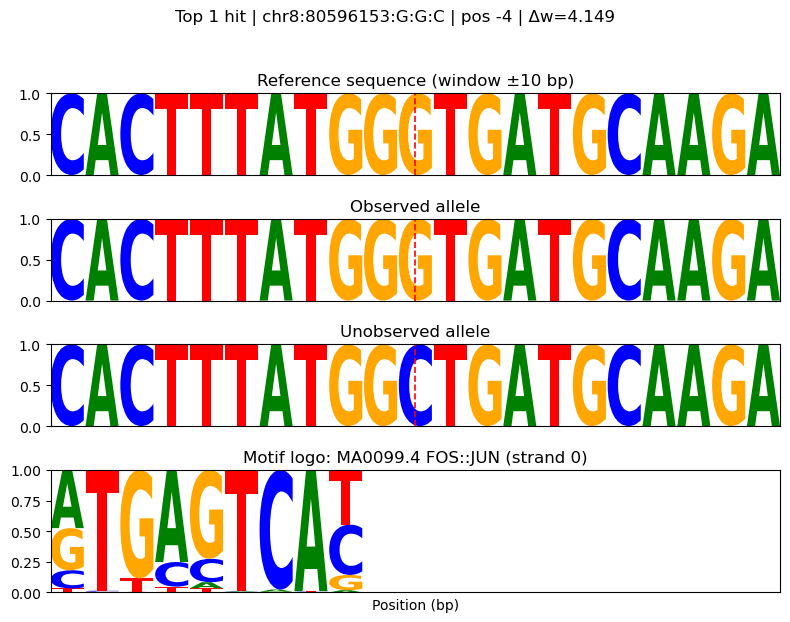

In [50]:
# pick one top hit
rank, (vi, pi) = 1, top_var_pos[0]
seq_id = lst_seq_idx[vi]
pos_rel = pi - (mat_dw.shape[1] // 2)

# get sequences (ref, obs, unobs)
seq_ref   = str(next(rec for rec in lst_seq_ref   if rec.id == seq_id).seq)
seq_obs   = str(next(rec for rec in lst_seq_obs   if rec.id == seq_id).seq)
seq_unobs = str(next(rec for rec in lst_seq_unobs if rec.id == seq_id).seq)

# choose a window around the variant position (e.g., ±10 bp)
flank = 10
center = len(seq_ref)//2
win_start = max(center - flank, 0)
win_end   = min(center + flank + 1, len(seq_ref))
seq_ref_win   = seq_ref[win_start:win_end]
seq_obs_win   = seq_obs[win_start:win_end]
seq_unobs_win = seq_unobs[win_start:win_end]

# convert sequences to one-hot DataFrames for logo plotting
def seq_to_df(seq):
    letters = list("ACGT")
    data = np.zeros((len(seq), 4))
    for i, base in enumerate(seq):
        if base in letters:
            data[i, letters.index(base)] = 1
    return pd.DataFrame(data, columns=letters)

df_ref   = seq_to_df(seq_ref_win)
df_obs   = seq_to_df(seq_obs_win)
df_unobs = seq_to_df(seq_unobs_win)

# prepare motif PWM from LODs (normalize to probs)
lods = dct_motif_lods[motif]
pwm = 2 ** lods
pwm = pwm / pwm.sum(axis=1, keepdims=True)
df_pwm = pd.DataFrame(pwm, columns=list("ACGT"))

# variant-relative position within the window
var_pos_in_win = center - win_start

# === Plot ===
fig, axes = plt.subplots(4, 1, figsize=(8,6), sharex=True, gridspec_kw={'height_ratios':[1,1,1,1.5]})
plt.subplots_adjust(hspace=0.3)

# Ref / Obs / Unobs as sequence logos
lm.Logo(df_ref, ax=axes[0], color_scheme='classic')
axes[0].set_title(f"Reference sequence (window ±{flank} bp)")
axes[0].axvline(var_pos_in_win, color='red', lw=1.2, ls='--', label='variant')

lm.Logo(df_obs, ax=axes[1], color_scheme='classic')
axes[1].set_title("Observed allele")
axes[1].axvline(var_pos_in_win, color='red', lw=1.2, ls='--')

lm.Logo(df_unobs, ax=axes[2], color_scheme='classic')
axes[2].set_title("Unobserved allele")
axes[2].axvline(var_pos_in_win, color='red', lw=1.2, ls='--')

# PWM logo for motif
lm.Logo(df_pwm, ax=axes[3], color_scheme='classic')
axes[3].set_title(f"Motif logo: {motif} (strand {strand})")
axes[3].set_xlabel("Position (bp)")

for ax in axes:
    ax.set_ylabel("")
    ax.legend().set_visible(False)
    ax.set_xticks([])

plt.suptitle(f"Top {rank} hit | {seq_id} | pos {pos_rel:+d} | Δw={mat_dw[vi,pi]:.3f}", y=1.03)
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


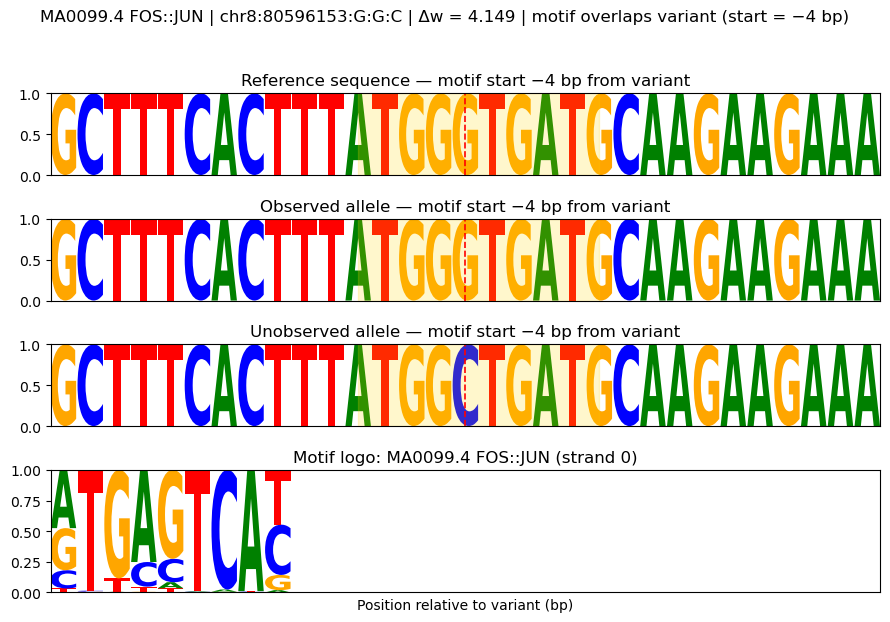

In [55]:
import logomaker as lm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

motif   = "MA0099.4 FOS::JUN"
strand  = 0
seq_id  = "chr8:80596153:G:G:C"
pos_rel = -4      # motif scanning window starts 4bp before variant
dw_val  = 4.149

# === Load sequences
seq_ref   = str(next(rec for rec in lst_seq_ref   if rec.id == seq_id).seq)
seq_obs   = str(next(rec for rec in lst_seq_obs   if rec.id == seq_id).seq)
seq_unobs = str(next(rec for rec in lst_seq_unobs if rec.id == seq_id).seq)

# === Define key positions
motif_len = dct_motif_lods[motif].shape[0]       # e.g. 19bp for FOS::JUN
variant_pos = len(seq_ref)//2                    # 36bp (center)
motif_start = variant_pos + pos_rel              # 32bp
motif_end   = motif_start + motif_len            # 32+19=51bp
flank = 15                                      # ±15bp around variant

# === Extract window around variant (centered at 36bp)
win_start = max(variant_pos - flank, 0)
win_end   = min(variant_pos + flank + 1, len(seq_ref))

seq_ref_win   = seq_ref[win_start:win_end]
seq_obs_win   = seq_obs[win_start:win_end]
seq_unobs_win = seq_unobs[win_start:win_end]

# === One-hot helper
def seq_to_df(seq):
    letters = list("ACGT")
    data = np.zeros((len(seq), 4))
    for i, base in enumerate(seq):
        if base in letters:
            data[i, letters.index(base)] = 1
    return pd.DataFrame(data, columns=letters)

df_ref   = seq_to_df(seq_ref_win)
df_obs   = seq_to_df(seq_obs_win)
df_unobs = seq_to_df(seq_unobs_win)

# === Motif PWM (normalize to probs)
lods = dct_motif_lods[motif]
pwm = 2 ** lods
pwm = pwm / pwm.sum(axis=1, keepdims=True)
df_pwm = pd.DataFrame(pwm, columns=list("ACGT"))

# === Compute positions in the window coordinate system
motif_start_rel = motif_start - win_start
motif_end_rel   = motif_end - win_start
variant_rel     = variant_pos - win_start

# === Plot
fig, axes = plt.subplots(4, 1, figsize=(9,6), sharex=True,
                         gridspec_kw={'height_ratios':[1,1,1,1.5]})
plt.subplots_adjust(hspace=0.3)

for ax, df, title in zip(
    axes[:3],
    [df_ref, df_obs, df_unobs],
    ["Reference sequence", "Observed allele", "Unobserved allele"]
):
    lm.Logo(df, ax=ax, color_scheme='classic')
    # motif window (yellow box)
    ax.axvspan(motif_start_rel, motif_end_rel, color='gold', alpha=0.2, label='motif window')
    # variant position (red dashed)
    ax.axvline(variant_rel, color='red', lw=1.2, ls='--', label='variant')
    ax.set_title(f"{title} — motif start −4 bp from variant")

# Motif logo
lm.Logo(df_pwm, ax=axes[3], color_scheme='classic')
axes[3].set_title(f"Motif logo: {motif} (strand {strand})")
axes[3].set_xlabel("Position relative to variant (bp)")
for ax in axes:
    ax.set_ylabel("")
    ax.legend().set_visible(False)
    ax.set_xticks([])

plt.suptitle(
    f"{motif} | {seq_id} | Δw = {dw_val:.3f} | motif overlaps variant (start = −4 bp)",
    y=1.03, fontsize=12
)
plt.tight_layout()
plt.show()
